## Optimizers with FashionMNIST

In [7]:
import torch
from torch import nn as nn, optim
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt

In [2]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100.0%
100.0%
100.0%
100.0%


In [3]:
train_loader = DataLoader(training_data, batch_size=64)
test_loader = DataLoader(test_data, batch_size=64)

In [4]:
for images, labels in train_loader:
    print(images.shape, labels.shape)
    break

torch.Size([64, 1, 28, 28]) torch.Size([64])


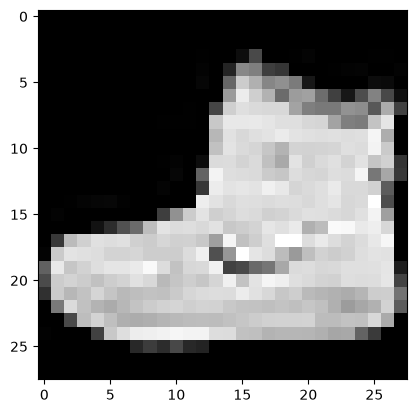

In [5]:
plt.imshow(images[0].squeeze(), cmap='gray')
plt.show()

In [8]:
class ClothesClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

In [14]:
model = ClothesClassifier()
# optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [15]:
epochs = 2
for epoch in range(epochs):
    for batch, (images, labels) in enumerate(train_loader):
        pred = model(images)
        loss = criterion(pred, labels)

        loss.backward()


        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            print(f"Batch: {batch}, Loss: {loss.item()}")

Batch: 0, Loss: 2.3277392387390137
Batch: 100, Loss: 0.8075173497200012
Batch: 200, Loss: 0.44487348198890686
Batch: 300, Loss: 0.6513342261314392
Batch: 400, Loss: 0.47185882925987244
Batch: 500, Loss: 0.4782131016254425
Batch: 600, Loss: 0.4508150517940521
Batch: 700, Loss: 0.6322523355484009
Batch: 800, Loss: 0.5607867240905762
Batch: 900, Loss: 0.5231029391288757
Batch: 0, Loss: 0.3343493938446045
Batch: 100, Loss: 0.41348376870155334
Batch: 200, Loss: 0.31895363330841064
Batch: 300, Loss: 0.4900472164154053
Batch: 400, Loss: 0.38441532850265503
Batch: 500, Loss: 0.3896709978580475
Batch: 600, Loss: 0.38141465187072754
Batch: 700, Loss: 0.517393946647644
Batch: 800, Loss: 0.4785915017127991
Batch: 900, Loss: 0.47314390540122986


In [16]:
# SGD without momentum (2.31 => 2.07)
# SGD with momentum(2.32 => 0.67)
# Adam (2.32 => 0.47)

In [17]:
model.eval()

all_predicted = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.numpy())
        all_predicted.extend(labels.numpy())

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

report = classification_report(all_labels, all_predicted)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00      1000
           2       1.00      1.00      1.00      1000
           3       1.00      1.00      1.00      1000
           4       1.00      1.00      1.00      1000
           5       1.00      1.00      1.00      1000
           6       1.00      1.00      1.00      1000
           7       1.00      1.00      1.00      1000
           8       1.00      1.00      1.00      1000
           9       1.00      1.00      1.00      1000

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

